## 📊 **Aqueous Solubility Prediction**

### 📌 **1. 프로젝트 개요**

#### **1-1. 프로젝트 개요**

분자 특성과 용해도 간의 관계를 단순 상관계수로 분석하는 데에는 한계가 있다고 판단하였다.  
일부 변수는 개별적으로는 영향이 작아 보이지만, 서로 결합될 경우 중요한 역할을 할 수 있기 때문이다.  

또한 모델 성능이 변수의 개수보다 어떤 변수를 선택하느냐에 더 크게 영향을 받을 수 있다고 생각하여,  
다양한 feature 조합을 구성하고 그에 따른 성능 변화를 분석하고자 본 프로젝트를 수행하였다.  
  
#### **1-2. 프로젝트 목표**
1. 분자 구조 기반 feature가 용해도에 미치는 영향을 분석한다.  

2. 다양한 머신러닝 모델을 적용하여 예측 성능을 비교한다.
3. feature 선택에 따른 모델 성능 변화를 분석하여, 효율적인 변수 구성을 도출한다.

### 📌 **2. 데이터 로드 및 이해**

In [1]:
import pandas as pd

data = "../data/aqueous_solubility_dataset.csv"
df = pd.read_csv(data)

df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


#### **데이터 설명**
- **Compound ID**: 화합물 이름  
- **Minimum Degree**: 원자 최소 결합 수  
- **Molecular Weight**: 분자 크기  
- **Number of H-Bond Donors**: 수소결합 제공 수  
- **Number of Rings**: 고리 개수  
- **Number of Rotatable Bonds**: 회전 가능한 결합 수  
- **Polar Surface Area**: 극성 표면적  
- **smiles**: 분자 구조 문자열  
  
- **Target**
  - measured log solubility in mols per litre

### 📌 **3. 상관관계 분석(EDA)**

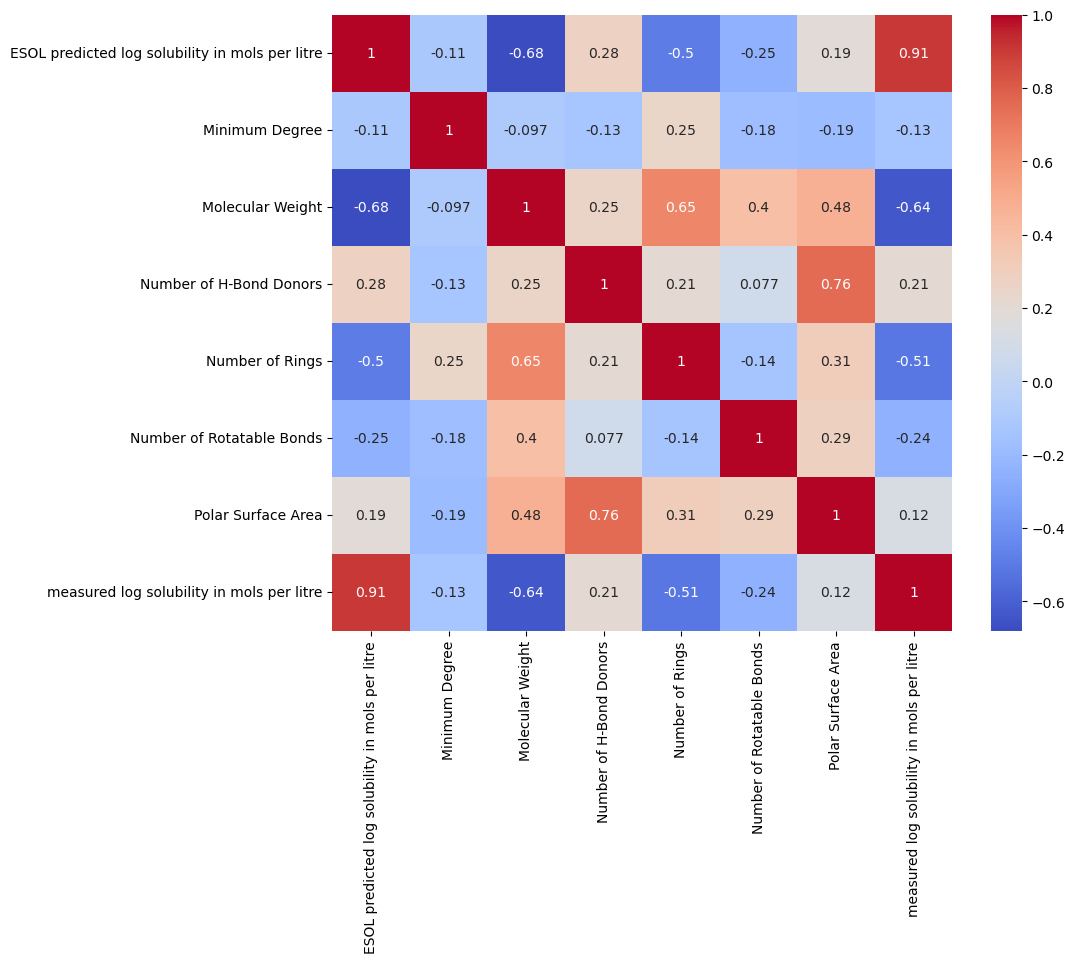

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [3]:
corr = df.corr(numeric_only=True)
corr["measured log solubility in mols per litre"].sort_values(ascending=False)

measured log solubility in mols per litre          1.000000
ESOL predicted log solubility in mols per litre    0.907264
Number of H-Bond Donors                            0.209429
Polar Surface Area                                 0.123210
Minimum Degree                                    -0.130445
Number of Rotatable Bonds                         -0.244256
Number of Rings                                   -0.512279
Molecular Weight                                  -0.640189
Name: measured log solubility in mols per litre, dtype: float64

#### **EDA 인사이트**

- 분자 크기가 클수록 용해도 감소  
- 고리 수가 많을수록 용해도 감소  
- 회전 결합 수 증가 → 용해도 감소  
- 수소결합 증가 → 용해도 증가  

👉 단, 단순 상관관계만으로는 복잡한 관계를 설명하기 어려움

### 📌 **4. Feature 구성**

In [4]:
# 핵심 변수
features_core = [
    "Molecular Weight",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Number of H-Bond Donors"
]

# 전체 변수
features_all = [
    "Minimum Degree",
    "Molecular Weight",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Polar Surface Area"
]

y = df["measured log solubility in mols per litre"]

X_core = df[features_core]
X_all = df[features_all]

### **📌 5. 데이터 분할**

In [5]:
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_core, y, test_size=0.2, random_state=42
)

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

### 📌 **6. RandomForest 모델 학습**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# core 모델
model_core = RandomForestRegressor(random_state=42)
model_core.fit(Xc_train, yc_train)

# all 모델
model_all = RandomForestRegressor(random_state=42)
model_all.fit(Xa_train, ya_train)

pred_core = model_core.predict(Xc_test)
pred_all = model_all.predict(Xa_test)

### 📌 **7. 모델 평가**

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_true, pred):
    return mean_squared_error(y_true, pred), r2_score(y_true, pred)

mse_core, r2_core = evaluate(yc_test, pred_core)
mse_all, r2_all = evaluate(ya_test, pred_all)

print("Core 모델:", mse_core, r2_core)
print("All 모델:", mse_all, r2_all)

Core 모델: 1.2501854092134308 0.7355114482770025
All 모델: 0.8250395461346641 0.8254550780522641


#### **결과 해석**

- All 모델이 Core 모델보다 성능이 더 좋음  
👉 더 많은 변수 고려가 효과적

### 📌 **8. Feature Importance 분석**

In [8]:
importance = pd.Series(model_all.feature_importances_, index=features_all)
importance.sort_values(ascending=False)

Molecular Weight             0.581690
Polar Surface Area           0.249139
Number of Rings              0.067752
Number of Rotatable Bonds    0.059884
Number of H-Bond Donors      0.037464
Minimum Degree               0.004070
dtype: float64

#### **해석**

일부 변수는 상관관계는 높지만 중요도가 낮음  
👉 다른 변수와 정보가 중복되기 때문  
  
반면 Polar Surface Area는 상관계수는 낮지만 중요도가 높게 나타남  
👉 변수 간 상호작용이 모델 예측에 영향을 주었기 때문

### 📌 **9. Reduced 모델**

In [9]:
features_reduced = [
    "Molecular Weight",
    "Polar Surface Area",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Number of H-Bond Donors"
]

X_reduced = df[features_reduced]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_reduced = RandomForestRegressor(random_state=42)
model_reduced.fit(Xr_train, yr_train)

pred_reduced = model_reduced.predict(Xr_test)

mse_reduced, r2_reduced = evaluate(yr_test, pred_reduced)

print("Reduced:", mse_reduced, r2_reduced)

Reduced: 0.8191246937919269 0.8267064210276794


### 📌 **10. Top2 모델 (비교용)**

In [10]:
features_top2 = ["Molecular Weight", "Number of Rings"]

X_top2 = df[features_top2]

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_top2, y, test_size=0.2, random_state=42
)

model_top2 = RandomForestRegressor(random_state=42)
model_top2.fit(Xt_train, yt_train)

pred_top2 = model_top2.predict(Xt_test)

mse_top2, r2_top2 = evaluate(yt_test, pred_top2)

print("Top2:", mse_top2, r2_top2)

Top2: 1.8593825616334771 0.6066300268734954


#### **결과 해석**
Reduced 모델 성능이 가장 좋고, Top2 모델은 성능 떨어짐  
👉 변수 수가 너무 적으면 성능 저하 발생

### 📌 **11. Linear Regression (비선형 검증)**

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

Xr_train_scaled = scaler.fit_transform(Xr_train)
Xr_test_scaled = scaler.transform(Xr_test)

lr = LinearRegression()
lr.fit(Xr_train_scaled, yr_train)

pred_lr = lr.predict(Xr_test_scaled)

mse_lr, r2_lr = evaluate(yr_test, pred_lr)

print("Linear:", mse_lr, r2_lr)

Linear: 1.4697211162997805 0.6890665923453652


#### **결과 해석**
👉 선형 모델 성능이 낮음  
→ 데이터는 비선형 구조를 가짐

### 📌 **12. XGBoost 비교**

In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(Xr_train, yr_train)

pred_xgb = xgb.predict(Xr_test)

print("XGB:", evaluate(yr_test, pred_xgb))

XGB: (0.8813868258479565, 0.8135342779092871)


### 📌 **13. 최종 결과**
| 모델 | MSE | R² |
|------|-----|----|
| Linear Regression | 1.47 | 0.689 |
| RandomForest (Core) | 1.25 | 0.735 |
| RandomForest (All) | 0.825 | 0.825 |
| RandomForest (Reduced) | **0.819** | **0.827** |
| XGBoost | 0.881 | 0.814 |

### 📌 **14. 결론**
- RandomForest (Reduced)가 가장 우수한 성능  
- 변수 수를 줄이면서도 성능 유지 가능  
- 데이터는 선형보다 비선형 구조에 가까움  

👉 복잡한 모델보다 데이터에 맞는 모델 선택이 중요